In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

df = pd.read_csv("../data/clean/gdelt_benin_clean.csv", low_memory=False)

# Date en datetime
df["date"] = pd.to_datetime(df["SQLDATE"], format="%Y-%m-%d")

## Chargement et nettoyage

In [2]:
# Supprimer les lignes sans coordonnées géographiques
df = df.dropna(subset=["ActionGeo_Lat", "ActionGeo_Long"])

# Supprimer les lignes sans GoldsteinScale
df = df.dropna(subset=["GoldsteinScale"])

print(f"Événements chargés : {len(df)}")
print(f"Période : {df['date'].min()} → {df['date'].max()}")

Événements chargés : 22778
Période : 2025-04-26 00:00:00 → 2026-04-26 00:00:00


##  Features de sévérité et de violence

In [3]:
df.columns

Index(['GLOBALEVENTID', 'SQLDATE', 'MonthYear', 'Year', 'FractionDate',
       'Actor1Code', 'Actor1Name', 'Actor1CountryCode', 'Actor1KnownGroupCode',
       'Actor1EthnicCode', 'Actor1Religion1Code', 'Actor1Religion2Code',
       'Actor1Type1Code', 'Actor1Type2Code', 'Actor1Type3Code', 'Actor2Code',
       'Actor2Name', 'Actor2CountryCode', 'Actor2KnownGroupCode',
       'Actor2EthnicCode', 'Actor2Religion1Code', 'Actor2Religion2Code',
       'Actor2Type1Code', 'Actor2Type2Code', 'Actor2Type3Code', 'IsRootEvent',
       'EventCode', 'EventBaseCode', 'EventRootCode', 'QuadClass',
       'GoldsteinScale', 'NumMentions', 'NumSources', 'NumArticles', 'AvgTone',
       'Actor1Geo_Type', 'Actor1Geo_FullName', 'Actor1Geo_CountryCode',
       'Actor1Geo_ADM1Code', 'Actor1Geo_ADM2Code', 'Actor1Geo_Lat',
       'Actor1Geo_Long', 'Actor1Geo_FeatureID', 'Actor2Geo_Type',
       'Actor2Geo_FullName', 'Actor2Geo_CountryCode', 'Actor2Geo_ADM1Code',
       'Actor2Geo_ADM2Code', 'Actor2Geo_Lat', 'Act

In [4]:
# Flag événement violent: codes CAMEO hostiles
VIOLENT_CODES = {
    14, 141, 142, 143, 144, 145,  # Protestations
    15, 151, 152, 153, 154,        # Menaces de force
    16, 160, 161, 162, 163, 164,  # Démonstrations de force
    17, 170, 171, 172, 173, 174,  # Réductions de droits
    18, 180, 181, 182, 183,        # Assauts
    19, 190, 191, 192, 193, 194,  # Combats
    20, 200, 201, 202, 203, 204,  # Violence de masse
}


df["is_violent"] = df["EventCode"].isin(VIOLENT_CODES).astype(int)

# Score de sévérité : GoldsteinScale inversé 
df["severity_score"] = (df["GoldsteinScale"] * -1).clip(lower=0)

# Pondération par le nombre d'articles (signal de magnitude médiatique)
df["weighted_severity"] = df["severity_score"] * np.log1p(df["NumArticles"])

df.head()

,GLOBALEVENTID,SQLDATE,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,Actor1Religion1Code,Actor1Religion2Code,Actor1Type1Code,Actor1Type2Code,Actor1Type3Code,Actor2Code,Actor2Name,Actor2CountryCode,Actor2KnownGroupCode,Actor2EthnicCode,Actor2Religion1Code,Actor2Religion2Code,Actor2Type1Code,Actor2Type2Code,Actor2Type3Code,IsRootEvent,EventCode,EventBaseCode,EventRootCode,QuadClass,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,Actor1Geo_Type,Actor1Geo_FullName,Actor1Geo_CountryCode,Actor1Geo_ADM1Code,Actor1Geo_ADM2Code,Actor1Geo_Lat,Actor1Geo_Long,Actor1Geo_FeatureID,Actor2Geo_Type,Actor2Geo_FullName,Actor2Geo_CountryCode,Actor2Geo_ADM1Code,Actor2Geo_ADM2Code,Actor2Geo_Lat,Actor2Geo_Long,Actor2Geo_FeatureID,ActionGeo_Type,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_ADM2Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL,year,month,week,date,is_violent,severity_score,weighted_severity
0,1248558842,2025-06-09,202506,2025,2025.4356,BEN,COTONOU,BEN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,1,70,70,7,2,7.0,20,1,10,3.267974,1,Benin,BN,BN,NaN,9.5000,2.25000,BN,0,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,1,Benin,BN,BN,NaN,9.5,2.25,BN,20250609020000,https://english.news.cn/20250609/833e6be5b34f4...,2025,6,24,2025-06-09,0,0.0,0.000000
1,1248561281,2025-06-09,202506,2025,2025.4356,NGA,BENIN CITY,NGA,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,1,173,173,17,4,-5.0,3,1,3,-3.353659,1,Benin,BN,BN,NaN,9.5000,2.25000,BN,0,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,1,Benin,BN,BN,NaN,9.5,2.25,BN,20250609023000,https://punchng.com/ndlea-intercepts-drugs-dis...,2025,6,24,2025-06-09,1,5.0,6.931472
2,1248560915,2025-06-09,202506,2025,2025.4356,BEN,BENIN,BEN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,NGA,BENIN CITY,NGA,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,1,173,173,17,4,-5.0,2,1,2,-3.353659,1,Benin,BN,BN,NaN,9.5000,2.25000,BN,1,Benin,BN,BN,NaN,9.5000,2.25000,BN,1,Benin,BN,BN,NaN,9.5,2.25,BN,20250609023000,https://punchng.com/ndlea-intercepts-drugs-dis...,2025,6,24,2025-06-09,1,5.0,5.493061
3,1248556983,2025-06-09,202506,2025,2025.4356,AFR,AFRICA,AFR,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,USAGOV,US OFFICIAL,USA,NaN,NaN,NaN,NaN,GOV,Unknown,Unknown,0,40,40,4,1,1.0,2,1,2,-1.637612,4,"Agadez, Agadez, Niger",NG,NG01,22553,16.9733,7.99111,-1077349,4,"Agadez, Agadez, Niger",NG,NG01,22553,16.9733,7.99111,-1077349,1,Benin,BN,BN,NaN,9.5,2.25,BN,20250609013000,https://www.eurasiareview.com/09062025-us-afri...,2025,6,24,2025-06-09,0,0.0,0.000000
4,1248557466,2025-06-09,202506,2025,2025.4356,USAGOV,US OFFICIAL,USA,NaN,NaN,NaN,NaN,GOV,Unknown,Unknown,AFR,AFRICA,AFR,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,0,40,40,4,1,1.0,1,1,1,-1.637612,4,"Agadez, Agadez, Niger",NG,NG01,22553,16.9733,7.99111,-1077349,4,"Agadez, Agadez, Niger",NG,NG01,22553,16.9733,7.99111,-1077349,1,Benin,BN,BN,NaN,9.5,2.25,BN,20250609013000,https://www.eurasiareview.com/09062025-us-afri...,2025,6,24,2025-06-09,0,0.0,0.000000


In [12]:
# Je vais essayer de reprendre en ne gardant que les lignes avec isRootEvent = 1

<Axes: xlabel='is_violent'>

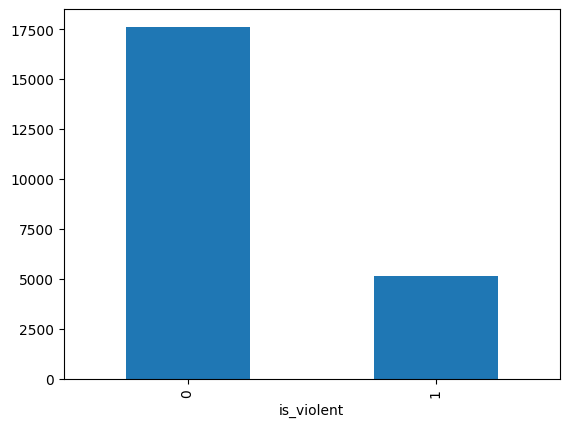

In [13]:
df['is_violent'].value_counts().plot.bar()

In [16]:
columns_of_interest = features_for_isolation_forest = [
    'GoldsteinScale', 
    'NumMentions', 
    'NumSources', 
    'NumArticles', 
    'AvgTone'
]

df_model = df[features_for_isolation_forest].dropna()
df_model.head()

,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone
0,7.0,20,1,10,3.267974
1,-5.0,3,1,3,-3.353659
2,-5.0,2,1,2,-3.353659
3,1.0,2,1,2,-1.637612
4,1.0,1,1,1,-1.637612


In [18]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_model)

# contamination: proportion estimée d'anomalies dans le dataset (ex: 5%)
model = IsolationForest(
    n_estimators=100, 
    contamination=0.05, 
    random_state=42
)

model.fit(data_scaled)

# Prédiction
# -1 indique une anomalie, 1 indique une donnée normale
df['anomaly_score'] = model.decision_function(data_scaled) # Score d'anomalie
df['is_anomaly'] = model.predict(data_scaled)

# Affichage des résultats
df[df['is_anomaly'] == -1].head()

,GLOBALEVENTID,SQLDATE,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,Actor1Religion1Code,Actor1Religion2Code,Actor1Type1Code,Actor1Type2Code,Actor1Type3Code,Actor2Code,Actor2Name,Actor2CountryCode,Actor2KnownGroupCode,Actor2EthnicCode,Actor2Religion1Code,Actor2Religion2Code,Actor2Type1Code,Actor2Type2Code,Actor2Type3Code,IsRootEvent,EventCode,EventBaseCode,EventRootCode,QuadClass,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,Actor1Geo_Type,Actor1Geo_FullName,Actor1Geo_CountryCode,Actor1Geo_ADM1Code,Actor1Geo_ADM2Code,Actor1Geo_Lat,Actor1Geo_Long,Actor1Geo_FeatureID,Actor2Geo_Type,Actor2Geo_FullName,Actor2Geo_CountryCode,Actor2Geo_ADM1Code,Actor2Geo_ADM2Code,Actor2Geo_Lat,Actor2Geo_Long,Actor2Geo_FeatureID,ActionGeo_Type,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_ADM2Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL,year,month,week,date,is_violent,severity_score,weighted_severity,anomaly_score,is_anomaly
0,1248558842,2025-06-09,202506,2025,2025.4356,BEN,COTONOU,BEN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,1,70,70,7,2,7.0,20,1,10,3.267974,1,Benin,BN,BN,NaN,9.5,2.25,BN,0,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,1,Benin,BN,BN,NaN,9.5,2.25,BN,20250609020000,https://english.news.cn/20250609/833e6be5b34f4...,2025,6,24,2025-06-09,0,0.0,0.000000,-0.030112,-1
72,1281667763,2025-12-31,202512,2025,2025.9890,ELI,ACTOR,Unknown,NaN,NaN,NaN,NaN,ELI,Unknown,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,0,20,20,2,1,3.0,20,2,20,-3.197057,1,Benin,BN,BN,NaN,9.5,2.25,BN,0,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,1,Benin,BN,BN,NaN,9.5,2.25,BN,20251231113000,https://www.leral.net/560-MILLIARDS-MOBILISES-...,2025,12,1,2025-12-31,1,0.0,0.000000,-0.193299,-1
75,1281698938,2025-12-31,202512,2025,2025.9890,BEN,BENIN,BEN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,BENMIL,BENIN,BEN,NaN,NaN,NaN,NaN,MIL,Unknown,Unknown,1,190,190,19,4,-10.0,2,1,2,-9.768010,1,Benin,BN,BN,NaN,9.5,2.25,BN,1,Benin,BN,BN,NaN,9.5,2.25,BN,1,Benin,BN,BN,NaN,9.5,2.25,BN,20251231164500,https://www.firstpost.com/world/2025-year-ende...,2025,12,1,2025-12-31,1,10.0,10.986123,-0.008275,-1
76,1281698939,2025-12-31,202512,2025,2025.9890,BEN,BENIN,BEN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,MIL,LIEUTENANT COLONEL,Unknown,NaN,NaN,NaN,NaN,MIL,Unknown,Unknown,1,190,190,19,4,-10.0,8,1,8,-9.768010,1,Benin,BN,BN,NaN,9.5,2.25,BN,1,Benin,BN,BN,NaN,9.5,2.25,BN,1,Benin,BN,BN,NaN,9.5,2.25,BN,20251231164500,https://www.firstpost.com/world/2025-year-ende...,2025,12,1,2025-12-31,1,10.0,21.972246,-0.025680,-1
77,1281698940,2025-12-31,202512,2025,2025.9890,BENMIL,BENIN,BEN,NaN,NaN,NaN,NaN,MIL,Unknown,Unknown,BEN,BENIN,BEN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,1,190,190,19,4,-10.0,2,1,2,-9.768010,1,Benin,BN,BN,NaN,9.5,2.25,BN,1,Benin,BN,BN,NaN,9.5,2.25,BN,1,Benin,BN,BN,NaN,9.5,2.25,BN,20251231164500,https://www.firstpost.com/world/2025-year-ende...,2025,12,1,2025-12-31,1,10.0,10.986123,-0.008275,-1


In [20]:
df['is_anomaly'].value_counts()

is_anomaly
 1    21640
-1     1138
Name: count, dtype: int64

In [54]:
colonnes_cles = ['SQLDATE', 'Actor1Name', 'Actor2Name', 'EventCode', 'ActionGeo_Lat', 'ActionGeo_Long']


anomalies_violentes = df[
    (df['is_anomaly'] == -1) & 
    (df['is_violent'] == 1) & 
    (df['IsRootEvent'] == 1)
].sort_values(by='weighted_severity', ascending=False) \
    .drop_duplicates(subset=colonnes_cles, keep='first') \
        .drop_duplicates(subset=['SOURCEURL'])


# Affichage des résultats
anomalies_violentes.head(20)

,GLOBALEVENTID,SQLDATE,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,Actor1Religion1Code,Actor1Religion2Code,Actor1Type1Code,Actor1Type2Code,Actor1Type3Code,Actor2Code,Actor2Name,Actor2CountryCode,Actor2KnownGroupCode,Actor2EthnicCode,Actor2Religion1Code,Actor2Religion2Code,Actor2Type1Code,Actor2Type2Code,Actor2Type3Code,IsRootEvent,EventCode,EventBaseCode,EventRootCode,QuadClass,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,Actor1Geo_Type,Actor1Geo_FullName,Actor1Geo_CountryCode,Actor1Geo_ADM1Code,Actor1Geo_ADM2Code,Actor1Geo_Lat,Actor1Geo_Long,Actor1Geo_FeatureID,Actor2Geo_Type,Actor2Geo_FullName,Actor2Geo_CountryCode,Actor2Geo_ADM1Code,Actor2Geo_ADM2Code,Actor2Geo_Lat,Actor2Geo_Long,Actor2Geo_FeatureID,ActionGeo_Type,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_ADM2Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL,year,month,week,date,is_violent,severity_score,weighted_severity,anomaly_score,is_anomaly
16614,1248135081,2025-06-06,202506,2025,2025.4274,COP,POLICE OFFICER,Unknown,NaN,NaN,NaN,NaN,COP,Unknown,Unknown,BEN,BENIN,BEN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,1,190,190,19,4,-10.0,20,1,20,-8.431615,4,"Tanougou, Atakora, Benin",BN,BN08,5874,10.81450,1.431010,-1336379,4,"Tanougou, Atakora, Benin",BN,BN08,5874,10.81450,1.43101,-1336379,4,"Tanougou, Atakora, Benin",BN,BN08,5874.0,10.81450,1.43101,-1336379,20250606014500,https://www.spacewar.com/afp/250605222330.i2el...,2025,6,23,2025-06-06,1,10.0,30.445224,-0.148615,-1
10941,1282878640,2026-01-08,202601,2026,2026.0219,BEN,BENIN,BEN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,MED,MEDIA,Unknown,NaN,NaN,NaN,NaN,MED,Unknown,Unknown,1,190,190,19,4,-10.0,20,2,20,-4.477108,1,Benin,BN,BN,NaN,9.50000,2.250000,BN,1,Benin,BN,BN,NaN,9.50000,2.25000,BN,1,Benin,BN,BN,NaN,9.50000,2.25000,BN,20260108163000,https://www.zawya.com/en/press-release/africa-...,2026,1,2,2026-01-08,1,10.0,30.445224,-0.201620,-1
20236,1258316026,2025-08-19,202508,2025,2025.6274,TGO,TOGO,TGO,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,1,190,190,19,4,-10.0,18,2,18,-7.544113,1,Togo,TO,TO,NaN,8.00000,1.166667,TO,0,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,1,Benin,BN,BN,NaN,9.50000,2.25000,BN,20250819070000,https://www.yahoo.com/news/articles/togo-tight...,2025,8,34,2025-08-19,1,10.0,29.444390,-0.195795,-1
22526,1259882137,2025-08-27,202508,2025,2025.6493,BEN,BENIN,BEN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,1,180,180,18,4,-9.0,20,1,20,-2.882401,1,Benin,BN,BN,NaN,9.50000,2.250000,BN,0,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,1,Benin,BN,BN,NaN,9.50000,2.25000,BN,20250827174500,https://maliactu.net/mopti-une-initiative-cito...,2025,8,35,2025-08-27,1,9.0,27.400702,-0.139246,-1
17771,1272358524,2025-11-04,202511,2025,2025.8329,Unknown,Unknown,Unknown,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,COP,POLICE,Unknown,NaN,NaN,NaN,NaN,COP,Unknown,Unknown,1,181,181,18,4,-9.0,14,1,14,-6.332498,0,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,1,Benin,BN,BN,NaN,9.50000,2.25000,BN,1,Benin,BN,BN,NaN,9.50000,2.25000,BN,20251104120000,https://leadership.ng/police-arrest-woman-for-...,2025,11,45,2025-11-04,1,9.0,24.372452,-0.059116,-1
2195,1248235049,2025-06-06,202506,2025,2025.4274,CRM,CRIMINAL,Unknown,NaN,NaN,NaN,NaN,CRM,Unknown,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,1,190,190,19,4,-10.0,10,1,10,-13.281250,1,Benin,BN,BN,NaN,9.50000,2.250000,BN,0,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,1,Benin,BN,BN,NaN,9.50000,2.25000,BN,20250606143000,https://leadership.ng/police-drag-19-to-court-...,2025,6,23,2025-06-06,1,10.0,23.978953,-0.038824,-1
1816,1240395320,2025-04-27,202504,2025,2025.3205,MOSUAF,ISLAMIC MILITANT,Unknown,NaN,NaN,MOS,NaN,UAF,Unknown,Unknown,BEN,BENIN,BEN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,1,190,190,19,4,-10.0,10,1,10,-10.416667,5,"Alibori, Alibori, Benin",BN,BN07,5865,11.33330,2.916670,9145861,5,"

In [52]:
df[df['GLOBALEVENTID']==1301274265]

,GLOBALEVENTID,SQLDATE,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,Actor1Religion1Code,Actor1Religion2Code,Actor1Type1Code,Actor1Type2Code,Actor1Type3Code,Actor2Code,Actor2Name,Actor2CountryCode,Actor2KnownGroupCode,Actor2EthnicCode,Actor2Religion1Code,Actor2Religion2Code,Actor2Type1Code,Actor2Type2Code,Actor2Type3Code,IsRootEvent,EventCode,EventBaseCode,EventRootCode,QuadClass,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,Actor1Geo_Type,Actor1Geo_FullName,Actor1Geo_CountryCode,Actor1Geo_ADM1Code,Actor1Geo_ADM2Code,Actor1Geo_Lat,Actor1Geo_Long,Actor1Geo_FeatureID,Actor2Geo_Type,Actor2Geo_FullName,Actor2Geo_CountryCode,Actor2Geo_ADM1Code,Actor2Geo_ADM2Code,Actor2Geo_Lat,Actor2Geo_Long,Actor2Geo_FeatureID,ActionGeo_Type,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_ADM2Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL,year,month,week,date,is_violent,severity_score,weighted_severity,anomaly_score,is_anomaly
4260,1301274265,2026-04-20,202604,2026,2026.3014,SEN,SENEGAL,SEN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,BEN,BENIN,BEN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,1,57,57,5,1,8.0,4,1,4,3.225806,4,"Dakar, Dakar, Senegal",SG,SG01,NaN,14.7367,-17.6339,-2266494,1,Benin,BN,BN,NaN,9.5,2.25,BN,1,Benin,BN,BN,NaN,9.5,2.25,BN,20260427183000,https://www.developingtelecoms.com/telecom-bus...,2026,4,17,2026-04-20,0,0.0,0.0,0.056284,1


In [53]:
len(df)

22778